In [1]:
setwd('/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb')
library(data.table)

[1] "d"         "f"         "files"     "phenotype"

In [2]:
d <- fread('data/phenotypes/filtered_phenotypes_binary.tsv')

In [3]:
files <- list.files('data/prs/scores', full.names = TRUE, pattern = "pgs.txt.gz")[14]

In [4]:
for (f in files){
    phenotype <- gsub("_pgs.txt.gz","",basename(f))
    prs <- fread(f)
    
}

ERROR: Error in fread(f): To read gz and bz2 files directly, fread() requires 'R.utils' package which cannot be found. Please install 'R.utils' using 'install.packages('R.utils')'.


In [31]:
prs <- fread('data/prs/scores/Alanine_aminotransferase_residual_pgs_chrom.txt.gz')
colnames(prs)[1] <- 'eid'

In [33]:
1000617 %in% prs$eid

[1] FALSE

In [21]:
covariates <- unlist(strsplit(readLines("data/phenotypes/covars1.csv"), split = ','))

In [22]:
d <- fread('data/phenotypes/filtered_covar_phenotypes_cts.tsv.gz')

In [23]:
d <- d[,c('eid',phenotype,covariates), with = FALSE]

In [25]:
mrg <- merge(d, prs, all.x = TRUE)

In [29]:
mrg #sum(is.na(mrg$chr13))

eid,Alanine_aminotransferase_residual,sex,age,age2,sex_age,ukbb.centre,PC1,PC2,PC3,⋯,chr13,chr14,chr15,chr16,chr17,chr18,chr19,chr20,chr21,chr22
<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1000028,-0.29213207,0,45,2025,-45,11014,-11.34000,3.304250,1.0000600,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
1000034,NA,0,61,3721,-61,11004,-7.59207,0.766548,1.6581500,⋯,-0.0167613809,-0.0076060514,-0.006291715,-0.0103966900,0.0181559083,-0.03516724,0.0000000000,0.0284493980,0.008765771,0.04759363
1000087,-0.02193837,1,65,4225,65,11010,-11.36170,3.991620,0.3904050,⋯,-0.0072708408,-0.0011603335,0.008281517,-0.0051574839,0.0042313133,-0.05056542,-0.0499884573,0.0308921116,0.028379463,0.08072675
1000118,-0.02165680,1,55,3025,55,11012,-12.72040,5.578300,0.1489500,⋯,0.0035810742,-0.0002364658,0.030865806,0.0153653380,-0.0091625016,-0.01359697,-0.0478970823,0.0219854918,0.018673064,0.09958374
1000120,0.02879216,0,46,2116,-46,11021,-11.03550,0.427943,-2.9036200,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
1000162,0.11254055,1,45,2025,45,11018,-11.43270,2.185500,-1.2076800,⋯,-0.0165696273,0.0119061392,0.021982788,0.0103070867,-0.0004372154,-0.03697437,-0.0115817336,0.0238520558,-0.006041608,0.07596919
1000171,-0.39753877,1,61,3721,61,11013,-12.83620,3.911810,-2.6398900,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
1000196,-0.15342631,0,66,4356,-66,11009,-12.79490,1.853010,-0.6644730,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
1000254,0.01002126,1,63,3969,63,11010,-13.34800,3.208940,-1.8762000,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [30]:
nrow(prs)

[1] 381244

In [45]:
enz <- fread('/well/lindgren/flassen/ressources/genesets/genesets/data/ubiquitin/dubs_e3_zhu.txt')
pfam <- fread('/well/lindgren/flassen/ressources/pfam/releases/pfam35.0//Pfam-A.clans.tsv.gz', header = FALSE)
colnames(pfam) <- c('csqs.domains.name','pfam.clan','pfam.type1','pfam.type2','pfam.description')

In [64]:
domains <- fread('data/domains/ukb_eur_wes_200k_domains_chr21.tsv.gz')


In [65]:
domains <- domains[domains$csqs.gene_id %in% enz$ensembl_gene_id, ]

In [87]:
domains <- domains[domains$consequence_category %in% c('pLoF','damaging_missense'),]

In [88]:
options(repr.matrix.max.rows=10, repr.matrix.max.cols=200)


In [89]:
uniq <- unique(domains$varid)

In [90]:
mrg <- merge(domains, pfam, all.x = TRUE)

In [91]:
mrg$csqs.gene_pheno <- NULL
mrg$csqs.hgvsc <- NULL
mrg$csqs.hgvsp <- NULL
mrg$csqs.hgvs_offset <- NULL
mrg$csqs.lof_info <- NULL
mrg$csqs.minimised <- NULL
mrg$csqs.domains.name <- NULL


In [92]:
start <- c('csqs.gene_symbol','csqs.most_severe_consequence','consequence_category','pfam.clan','pfam.type1', 'pfam.type2', 'pfam.description')
mrg <- cbind(mrg[,colnames(mrg) %in% start, with = FALSE], mrg[,! colnames(mrg) %in% start, with = FALSE])

In [93]:
mrg

csqs.gene_symbol,csqs.most_severe_consequence,consequence_category,pfam.clan,pfam.type1,pfam.type2,pfam.description,locus,alleles,rsid,info.AC,info.AF,info.AN,MAF,MAC,varid,csqs.allele_num,csqs.amino_acids,csqs.biotype,csqs.canonical,csqs.ccds,csqs.cdna_start,csqs.cdna_end,csqs.cds_end,csqs.cds_start,csqs.codons,csqs.consequence_terms,csqs.distance,csqs.domains.db,csqs.exon,csqs.gene_id,csqs.gene_symbol_source,csqs.hgnc_id,csqs.impact,csqs.intron,csqs.lof,csqs.lof_flags,csqs.lof_filter,csqs.polyphen_prediction,csqs.polyphen_score,csqs.protein_end,csqs.protein_start,csqs.protein_id,csqs.sift_prediction,csqs.strand,csqs.swissprot,csqs.transcript_id,csqs.trembl,csqs.uniparc,csqs.variant_allele,csqs.revel_score,csqs.cadd_phred,csqs.csq_score
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<int>,<dbl>,<int>,<dbl>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<int>,<lgl>,<chr>,<lgl>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>
USP25,stop_gained,pLoF,NA,NA,NA,NA,chr21:15730403,"[""G"",""T""]",NA,2,5.6524e-06,353830,5.6524e-06,2,chr21:15730403:G:T,1,E/*,protein_coding,1,CCDS63336.1,379,379,10,10,Gag/Tag,"[""stop_gained""]",NA,Gene3D,1/26,ENSG00000155313,HGNC,HGNC:12624,HIGH,NA,HC,NA,NA,NA,NA,4,4,ENSP00000383044,NA,1,NA,ENST00000400183,NA,NA,T,NA,43,3
USP25,stop_gained,pLoF,NA,NA,NA,NA,chr21:15730433,"[""C"",""T""]",NA,1,2.8263e-06,353824,2.8263e-06,1,chr21:15730433:C:T,1,Q/*,protein_coding,1,CCDS63336.1,409,409,40,40,Cag/Tag,"[""stop_gained""]",NA,Gene3D,1/26,ENSG00000155313,HGNC,HGNC:12624,HIGH,NA,HC,NA,NA,NA,NA,14,14,ENSP00000383044,NA,1,NA,ENST00000400183,NA,NA,T,NA,40,3
USP25,frameshift_variant,pLoF,NA,NA,NA,NA,chr21:15762916,"[""TGA"",""T""]",NA,2,5.6524e-06,353830,5.6524e-06,2,chr21:15762916:TGA:T,1,LR/LX,protein_coding,1,CCDS63336.1,441,442,73,72,ctGAga/ctga,"[""frameshift_variant""]",NA,Gene3D,2/26,ENSG00000155313,HGNC,HGNC:12624,HIGH,NA,HC,NA,NA,NA,NA,25,24,ENSP00000383044,NA,1,NA,ENST00000400183,NA,NA,-,NA,NA,4
LTN1,frameshift_variant,pLoF,NA,NA,NA,NA,chr21:28984783,"[""GC"",""G""]",NA,1,2.8266e-06,353782,2.8266e-06,1,chr21:28984783:GC:G,1,A/X,protein_coding,1,CCDS33527.2,635,635,622,622,Gct/ct,"[""frameshift_variant""]",NA,Gene3D,4/30,ENSG00000198862,HGNC,HGNC:13082,HIGH,NA,HC,NA,NA,NA,NA,208,208,ENSP00000478783,NA,-1,NA,ENST00000614971,NA,NA,-,NA,NA,4
LTN1,frameshift_variant,pLoF,NA,NA,NA,NA,chr21:28984856,"[""TC"",""T""]",NA,1,2.8265e-06,353796,2.8265e-06,1,chr21:28984856:TC:T,1,K/X,protein_coding,1,CCDS33527.2,562,562,549,549,aaG/aa,"[""frameshift_variant""]",NA,Gene3D,4/30,ENSG00000198862,HGNC,HGNC:13082,HIGH,NA,HC,NA,NA,NA,NA,183,183,ENSP00000478783,NA,-1,NA,ENST00000614971,NA,NA,-,NA,NA,4
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
USP16,stop_gained,pLoF,NA,NA,NA,NA,chr21:29046673,"[""C"",""T""]",NA,21,5.9351e-05,353830,5.9351e-05,21,chr21:29046673:C:T,1,R/*,protein_coding,1,CCDS13583.1,1594,1594,1363,1363,Cga/Tga,"[""stop_gained""]",NA,MobiDB_lite,15/19,ENSG00000156256,HGNC,HGNC:12614,HIGH,NA,HC,NA,NA,NA,NA,455,455,ENSP00000334808,NA,1,NA,ENST00000334352,NA,NA,T,NA,40,3
USP16,stop_gained,pLoF,NA,NA,NA,NA,chr21:29046679,"[""C"",""T""]",NA,4,1.1305e-05,353830,1.1305e-05,4,chr21:29046679:C:T,1,Q/*,protein_coding,1,CCDS13583.1,1600,1600,1369,1369,Caa/Taa,"[""stop_gained""]",NA,MobiDB_lite,15/19,ENSG00000156256,HGNC,HGNC:12614,HIGH,NA,HC,NA,NA,NA,NA,457,457,ENSP00000334808,NA,1,NA,ENST00000334352,NA,NA,T,NA,42,3
USP16,stop_gained,pLoF,NA,NA,NA,NA,chr21:29046679,"[""C"",""T""]",NA,4,1.1305e-05,353830,1.1305e-05,4,chr21:29046679:C:T,1,Q/*,protein_coding,1,CCDS13583.1,1600,1600,1369,1369,Caa/Taa,"[""stop_gained""]",NA,MobiDB_lite,15/19,ENSG00000156256,HGNC,HGNC:12614,HIGH,NA,HC,NA,NA,NA,NA,457,457,ENSP00000334808,NA,1,NA,ENST00000334352,NA,NA,T,NA,42,3


In [134]:
d <- fread('data/domains/ukb_eur_wes_200k_ubiqitin.txt')
colnames(d)

[1] "csqs.gene_symbol"             "csqs.most_severe_consequence"
 [3] "consequence_category"         "pfam.clan"                   
 [5] "pfam.type1"                   "pfam.type2"                  
 [7] "pfam.description"             "locus"                       
 [9] "alleles"                      "info.AC"                     
[11] "info.AF"                      "info.AN"                     
[13] "MAF"                          "MAC"                         
[15] "varid"                        "csqs.allele_num"             
[17] "csqs.amino_acids"             "csqs.biotype"                
[19] "csqs.canonical"               "csqs.ccds"                   
[21] "csqs.cdna_start"              "csqs.cdna_end"               
[23] "csqs.cds_end"                 "csqs.cds_start"              
[25] "csqs.codons"                  "csqs.consequence_terms"      
[27] "csqs.distance"                "csqs.domains.db"             
[29] "csqs.exon"                    "csqs.gene_id"                
[31] "csqs.gene_symbol_source"      "csqs.hgnc_id"                
[33] "csqs.impact"                  "csqs.intron"                 
[35] "csqs.lof"                     "csqs.lof_flags"              
[37] "csqs.lof_filter"              "csqs.polyphen_prediction"    
[39] "csqs.polyphen_score"          "csqs.protein_end"            
[41] "csqs.protein_start"           "csqs.protein_id"             
[43] "csqs.sift_prediction"         "csqs.strand"                 
[45] "csqs.swissprot"               "csqs.transcript_id"          
[47] "csqs.trembl"                  "csqs.uniparc"                
[49] "csqs.variant_allele"          "csqs.revel_score"            
[51] "csqs.cadd_phred"              "csqs.csq_score"              
[53] "chr"

In [147]:
d <- d[,c("csqs.gene_symbol", "chr","locus","csqs.codons", "csqs.amino_acids","csqs.protein_end","csqs.protein_start", "csqs.most_severe_consequence", "consequence_category","info.AC","MAF",'pfam.type1','pfam.type2','pfam.description','csqs.protein_id', 'csqs.transcript_id','csqs.gene_id')]
d <- d[!duplicated(d),]
d$chr <- as.numeric(d$chr)
d <- d[!is.na(d$chr),]
d <- d[order(d$chr),]

In [149]:
fwrite(d, 'data/22MAR24_E3_DUBs_wes200k_EUR_damaging_mutations.txt', sep = '\t', quote = FALSE)

In [151]:
library(ggplot2)

Warning message:
"Removed 21 rows containing non-finite values (stat_bin)."


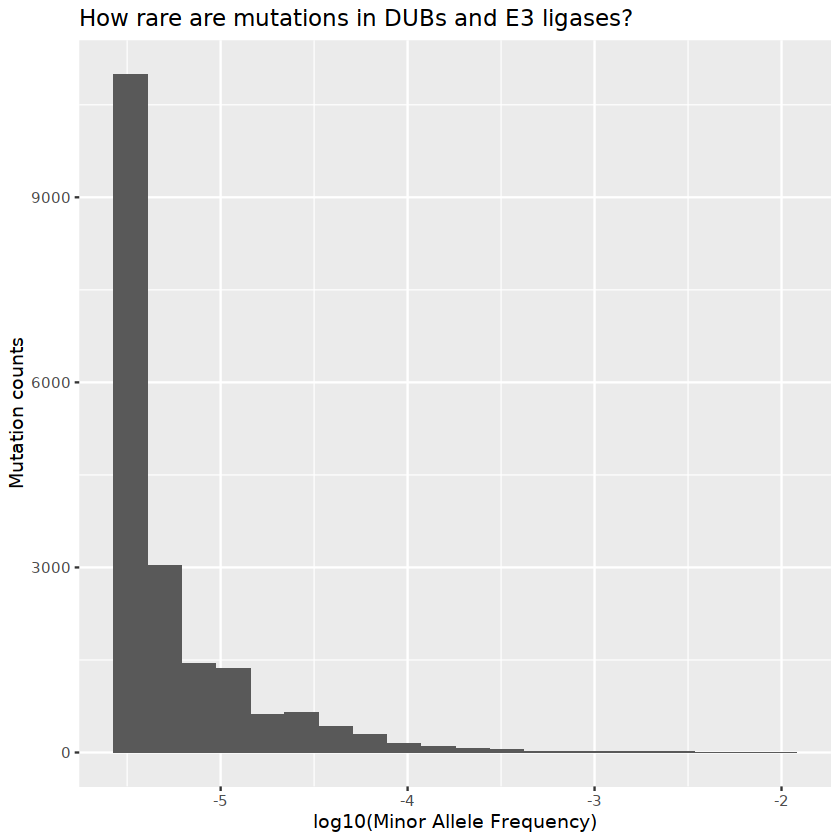

In [157]:
ggplot(d, aes(x=log10(as.numeric(MAF)))) +
    geom_histogram(bins = 20) +
    xlab("log10(Minor Allele Frequency)") +
    ylab('Mutation counts') +
    ggtitle('How rare are mutations in DUBs and E3 ligases?')